In [12]:
## 2026.08.12 CODEX HCC twin of Xenium_lung/Lung_train_validate_cv_UNIlabel_all.ipynb
## Cross-dataset training on all 36 ALIGNED annotated MATCHED_HE regions
##
## CLI equivalent:
##   conda run --no-capture-output -n SeededNTM python -u \
##     code/CODEX_hcc/HCC_train_validate_cv_UNIlabel.py --mode cross-dataset \
##     --use-spatial-context --spatial-k 8 --spatial-mode mean \
##     --pooled-save-result result_all_spatial
##
## Hierarchy (three-head):
##   L2  = final_CT          (fine / celltype_level2)
##   L12 = final_sublineage  (intermediate / celltype_level1)
##   L1  = final_lineage     (coarse / celltype_level0)
##
## Preprocess CSVs first:
##   conda run -n SeededNTM python code/CODEX_hcc/match_codex_cells_with_pixel.py
## Env: conda activate SeededNTM


In [13]:
## HCC_train_validate_cv_UNIlabel_all.ipynb
## Pool HE/{MATCHED_HE}/{MATCHED_HE}_matched_features.h5ad → dataset-level CV
## Outputs under: data/CODEX/HCC/Michael_data_transfer/s4769/{save_result}/
## StarDist per-sample plots: .../{save_result}/stardist/{MATCHED_HE}/
## Show three levels: L2 / L12 / L1 prediction results


In [14]:
import os

import warnings

# Keep notebook output clean.
warnings.filterwarnings("ignore")

# Choose physical GPU (string). Restart kernel after changing.
os.environ.setdefault("NCRT_CUDA_DEVICE", "0")
# Runtime env (GPU pin + tmpdir) before torch import.
# Ensure Hist2Pheno_pkg is importable before importing runtime helpers.
import sys as _sys
_pkg_dir = "/home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg"
if _pkg_dir not in _sys.path:
    _sys.path.insert(0, _pkg_dir)

from runtime_env import configure_notebook_runtime
_rt_env = configure_notebook_runtime()
NCRT_PHYSICAL_GPU = _rt_env["physical_gpu"]


CUDA_VISIBLE_DEVICES=0 (physical GPU 0)


In [29]:

import sys
import importlib
import pandas as pd
from pathlib import Path

path = "/home/lingyu/ssd2/Python/"
for _d in (
    f"{path}Hist2Pheno/code/Hist2Pheno_pkg",
    f"{path}Hist2Pheno/code/CODEX_hcc",
):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import base
import plot
import model as model_pkg
importlib.reload(base)
importlib.reload(plot)
importlib.reload(model_pkg)

import uni_label_cv_helpers as uni_nb
importlib.reload(uni_nb)

import HCC_train_validate_cv_UNIlabel as hcc_cli
importlib.reload(hcc_cli)

print("Imports OK")
print(f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')} (physical GPU {NCRT_PHYSICAL_GPU})")


Loading dependencies...
Imports OK
CUDA_VISIBLE_DEVICES=0 (physical GPU 0)


In [16]:
## CUDA/CPU sanity check + reproducibility (delegated to Hist2Pheno_pkg)
import torch
import random
import numpy as np
from torch_runtime import configure_torch_runtime

SEED = 42
_rt = configure_torch_runtime(seed=SEED)

# Keep the same variable names used downstream.
device = _rt.device
amp_scaler = _rt.amp_scaler
CUDA_DEVICE_INDEX = _rt.cuda_device_index
PHYSICAL_GPU = _rt.physical_gpu


/nobackup2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
CUDA_VISIBLE_DEVICES='0' -> physical GPU(s) '0'
Using physical GPU 0 as logical cuda:0 | NVIDIA RTX PRO 6000 Blackwell Server Edition
device: cuda:0 | physical GPU 0 | NVIDIA RTX PRO 6000 Blackwell Server Edition
Reproducibility configured with SEED=42


## Cross-dataset training (all 36 ALIGNED HCC regions)

Pool pre-built `{MATCHED_HE}_matched_features.h5ad`, run **dataset-level 5-fold CV** (~70% train / ~30% test), then StarDist on **each** region for **three heads** (L2 / L12 / L1).

**Outputs:** `s4769/{save_result}/`

- Internal validation (OOF): L2 + L1 + L12 confusion matrices
- StarDist: `s4769/{save_result}/stardist/{MATCHED_HE}/`

Run cells **in order** after kernel restart.

Set `QUICK_VALIDATE = True` in the config cell for a 3-sample smoke test.


In [17]:
from uni_label_cv_helpers import (
    RESULT_FIG,
    make_pooled_result_fig,
    make_pooled_stardist_result_fig,
    _auroc_csv_path_from_metrics,
    ensure_lp_extra_insample_preds,
    plot_he_confusion_matrices,
)
from model import predict_all_label_heads
from plot import plot_confusion_matrix

S4769_ROOT = Path(f"{path}Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769")
DATA_ROOT = S4769_ROOT  # pooled outputs under s4769/{save_result}/
CASES_ROOT = S4769_ROOT / "HE"
save_result = "result_all_spatial"

# Quick smoke test: 3 datasets, 2-fold, 1 epoch
QUICK_VALIDATE = False
VALIDATION_SUBSET = [
    "awy-98938_aligned_0d535a74",
    "awy-98938_aligned_8ded610e",
    "awy-98938_aligned_a5afeef9",
]

# Discover 36 ALIGNED annotated regions; build missing HE h5ads if needed
all_samples = hcc_cli.discover_hcc_samples(CASES_ROOT, require_h5ad=False, require_cells_csv=True)
_acq_map = hcc_cli.load_he_acq_map(CASES_ROOT)
_target = VALIDATION_SUBSET if QUICK_VALIDATE else all_samples
for _s in _target:
    _h5 = CASES_ROOT / _s / f"{_s}_matched_features.h5ad"
    if _h5.is_file():
        continue
    print(f"Building HE h5ad for {_s} ...", flush=True)
    _ctx = hcc_cli.RunContext(
        sample=_s,
        cases_root=CASES_ROOT,
        python_root=Path(path),
        therapy_data=_s,
        therapy_model=hcc_cli.DEFAULT_THERAPY_MODEL,
        save_result="result",
        device=device,
        seed=SEED,
        match_tolerance=1.0,
        column_rename=dict(hcc_cli.HCC_COLUMN_RENAME),
        force_rebuild_h5ad=False,
        input_dim=None,
        hidden_dims=(1024, 512, 256),
        cv_k=5,
        stratify_target="joint",
        patience=10,
        max_epochs=50,
        train_batch_size=4096,
        resume_from_checkpoints=True,    # Re-Train or Load from checkpoint!!!
        ablation_tag="D_emph_L2_spatial",
        hce_w1=1.0, hce_w2=2.0, hce_w12=1.0, hce_w_l12head=1.0, hce_w_l3=1.0, hce_w_l4=1.0,
        build_stardist_h5ad=False,
        acq_id=_acq_map[_s],
        use_spatial_context=True,
        spatial_k=8,
        spatial_mode="mean",
    )
    hcc_cli.step_he_h5ad(_ctx)

POOLED_SAMPLES = hcc_cli.discover_hcc_samples(
    CASES_ROOT,
    sample=None,
    require_h5ad=True,
)
if QUICK_VALIDATE:
    POOLED_SAMPLES = [s for s in VALIDATION_SUBSET if s in POOLED_SAMPLES]
print(f"Cross-dataset: {len(POOLED_SAMPLES)} datasets (HCC three-head)")

pooled_result_fig, pooled_result_dir = make_pooled_result_fig(DATA_ROOT, save_result)
FIG = RESULT_FIG
print(f"Results → {pooled_result_dir}")

POOLED_CV_K = 2 if QUICK_VALIDATE else 5
POOLED_MAX_EPOCHS = 1 if QUICK_VALIDATE else 50
POOLED_PATIENCE = 1 if QUICK_VALIDATE else 10
POOLED_TRAIN_GROUP_FRAC = 0.7
POOLED_TRAIN_BATCH_SIZE = 256 if QUICK_VALIDATE else 4096
POOLED_USE_SPATIAL = True  # lung defaults
POOLED_SPATIAL_K = 8
POOLED_SPATIAL_MODE = "mean"
if POOLED_USE_SPATIAL and not QUICK_VALIDATE:
    POOLED_ABLATION_TAG = "D_emph_L2_spatial_bs4096"
elif QUICK_VALIDATE:
    POOLED_ABLATION_TAG = "D_emph_L2_smoke"
else:
    POOLED_ABLATION_TAG = "D_emph_L2"
POOLED_HIDDEN_DIMS = (1024, 512, 256)
POOLED_HCE = dict(hce_w1=1.0, hce_w2=2.0, hce_w12=1.0, hce_w_l12head=1.0, hce_w_l3=1.0, hce_w_l4=1.0)
# HCC: sum of L2+L1+L12 macro AUROC
POOLED_VAL_SELECTION = hcc_cli.DEFAULT_VAL_SELECTION_METRIC  # three_tier_auc_sum
POOLED_CV_SELECTION = hcc_cli.DEFAULT_CV_SELECTION_METRIC

pooled_ctx = hcc_cli.PooledRunContext(
    data_root=DATA_ROOT,
    cases_root=CASES_ROOT,
    python_root=Path(path),
    samples=POOLED_SAMPLES,
    device=device,
    seed=SEED,
    save_result=save_result,
    input_dim=None,
    hidden_dims=POOLED_HIDDEN_DIMS,
    cv_k=POOLED_CV_K,
    train_group_frac=POOLED_TRAIN_GROUP_FRAC,
    patience=POOLED_PATIENCE,
    max_epochs=POOLED_MAX_EPOCHS,
    train_batch_size=POOLED_TRAIN_BATCH_SIZE,
    resume_from_checkpoints=not QUICK_VALIDATE,
    ablation_tag=POOLED_ABLATION_TAG,
    val_selection_metric=POOLED_VAL_SELECTION,
    cv_selection_metric=POOLED_CV_SELECTION,
    use_spatial_context=POOLED_USE_SPATIAL,
    spatial_k=POOLED_SPATIAL_K,
    spatial_mode=POOLED_SPATIAL_MODE,
    **POOLED_HCE,
)

print(f"Selection: val={POOLED_VAL_SELECTION}, cv={POOLED_CV_SELECTION}")
print(f"Ablation tag: {POOLED_ABLATION_TAG}, batch_size={POOLED_TRAIN_BATCH_SIZE}")
if POOLED_USE_SPATIAL:
    print(f"Spatial context: k={POOLED_SPATIAL_K}, mode={POOLED_SPATIAL_MODE!r}")
print("Three-head levels: L2=final_CT | L12=final_sublineage | L1=final_lineage")


Cross-dataset: 36 datasets (HCC three-head)
Results → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial
Selection: val=three_tier_auc_sum, cv=three_tier_auc_sum
Ablation tag: D_emph_L2_spatial_bs4096, batch_size=4096
Spatial context: k=8, mode='mean'
Three-head levels: L2=final_CT | L12=final_sublineage | L1=final_lineage


## 1. Load pooled h5ad & prep CV arrays


In [18]:
hcc_cli.step_pooled_prepare(pooled_ctx)

cv_data = pooled_ctx.g["cv_data"]
scaler = pooled_ctx.g["scaler"]
class_names = pooled_ctx.g["class_names"]
class_names_level1 = pooled_ctx.g["class_names_level1"]
class_names_level12 = pooled_ctx.g.get("class_names_level12")
input_dim = pooled_ctx.g["input_dim"]

print(f"Pooled: {cv_data['X_f'].shape[0]:,} cells × {input_dim}")
print(f"L2 classes: {len(class_names)} | L12: {len(class_names_level12) if class_names_level12 is not None else 0} | L1: {len(class_names_level1)}")
print(f"datasets: {len(set(cv_data['groups_f']))}")
print(f"USE_THREE_HEAD={pooled_ctx.g.get('USE_THREE_HEAD')}")



[Pooled prepare] 36 datasets
  awy-98938_aligned_0d535a74: 33,037 cells
  awy-98938_aligned_8ded610e: 12,291 cells
  awy-98938_aligned_a5afeef9: 42,444 cells
  awy-98938_aligned_59f27598: 33,257 cells
  nwn-95916_aligned_d1ec33a2: 8,491 cells
  nwn-95916_aligned_b16cf712: 20,135 cells
  nwn-95916_aligned_459f2ffd: 66,465 cells
  nwn-95916_aligned_737dafc9: 70,086 cells
  dpn-56105_aligned_b32cf147: 15,981 cells
  dpn-56105_aligned_d24763ad: 13,248 cells
  dpn-56105_aligned_85543451: 26,279 cells
  kqr-83230_aligned_5b50bc37: 26,360 cells
  kqr-83230_aligned_6f5021e3: 16,061 cells
  kqr-83230_aligned_3bba12d6: 41,842 cells
  kqr-83230_aligned_b24a3fb5: 33,152 cells
  fcu-91631_aligned_7ffa2d5a: 17,177 cells
  fcu-91631_aligned_2e321bd1: 8,078 cells
  fcu-91631_aligned_4722207f: 26,024 cells
  fcu-91631_aligned_1e3c06f5: 34,265 cells
  xid-87175_aligned_6a382a5d: 17,223 cells
  xid-87175_aligned_b5f82f61: 22,834 cells
  xid-87175_aligned_c06f7c7e: 38,248 cells
  lvr-76315_aligned_5c66cd

## 2. Group K-fold training

Dataset-level CV: each fold trains on ~70% datasets, validates on held-out ~30%.

Checkpoint selection: `three_tier_auc_sum` (L2 + L1 + L12 macro AUROC).


In [19]:
hcc_cli.step_pooled_train(pooled_ctx)

LP = pooled_ctx.g["LP"]
model = pooled_ctx.g["model"]
BEST_MLP_CHECKPOINT = pooled_ctx.g["BEST_MLP_CHECKPOINT"]
print(f"Best checkpoint: {BEST_MLP_CHECKPOINT}")
print(f"Best fold: {LP['best_fold'].get('fold')}")



[Pooled train] group CV k=5 train_frac=0.7 tag=D_emph_L2_spatial_bs4096 val_sel=three_tier_auc_sum cv_sel=three_tier_auc_sum spatial_k=8
Spatial context: k=8, mode='mean', per-sample kNN, neighbor_index shape=(1092742, 8)
Train dataset size: 815037
Val dataset size: 277705
Batch size: 4096
Feature dimension: 1024

Group CV fold 0: train_groups=26/36, held_out=10 group(s) (8, 12, 13, 16, 17, 21, 26, 30, 31, 35)
  Resume: checkpoint exists, skip training → /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_bs4096/hce_group_fold_0.pt
checkpoint_exists=True: loading checkpoint (no training): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_bs4096/hce_group_fold_0.pt
Loaded existing checkpoint metrics: accuracy=0.2593, weighted_f1=0.2362, macro_f1=0.1860
Train dataset size: 863178
Val dataset size: 229564
Batch siz

## 3. Internal validation (OOF) — three levels

- **L2**: OOF confusion + macro AUROC (from group CV)
- **L1 / L12**: in-sample predictions from the best-fold three-head model (with spatial kNN if enabled)



[Cross-dataset OOF Level2] confusion matrix (L2)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/conf_matrix_level2.pdf


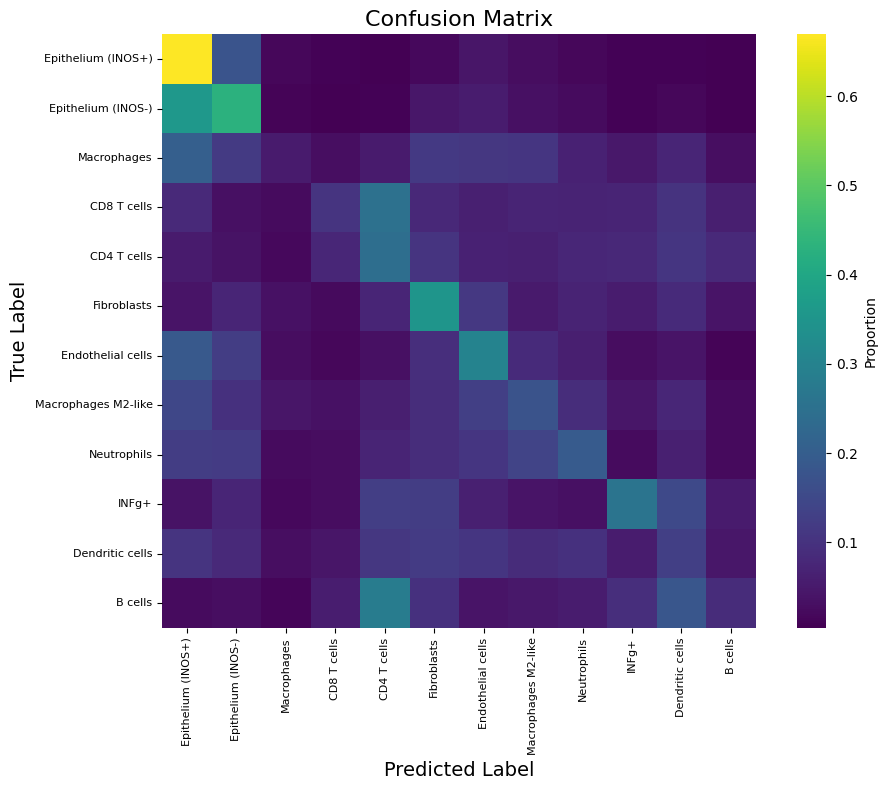

  L2 macro AUROC (OOF): 0.7608
  ROC colors: codex_hcc_fine (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/roc_internal_level2_oof.pdf


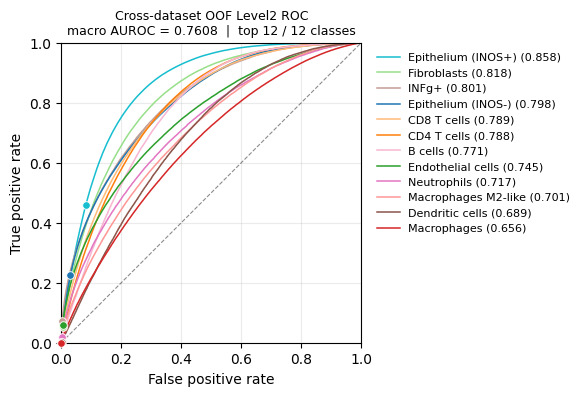


[Three-level internal] confusion matrices → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial

L2 celltype
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/conf_matrix_level2.pdf


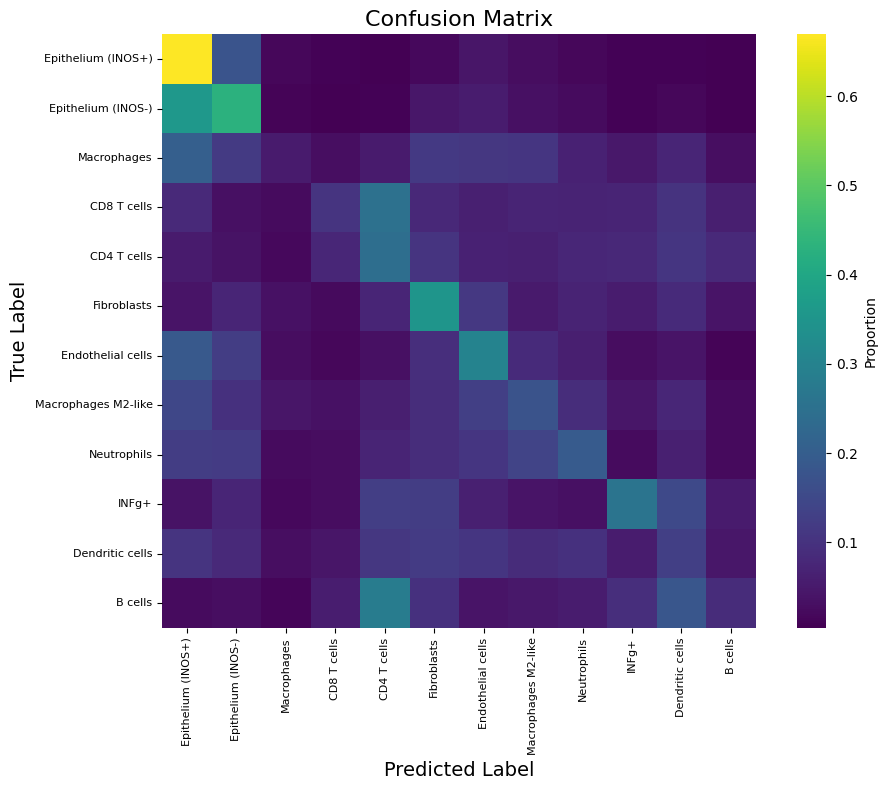


L1 lineage (L2→L1 agg)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/conf_matrix_level1.pdf


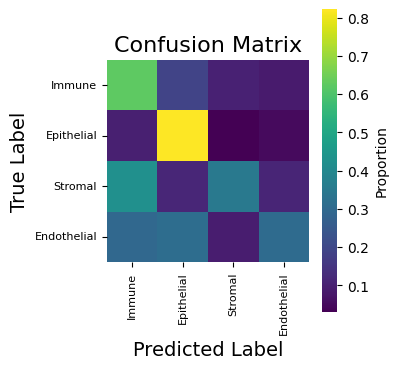


L1 lineage (L1 head)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/conf_matrix_level1_L1head.pdf


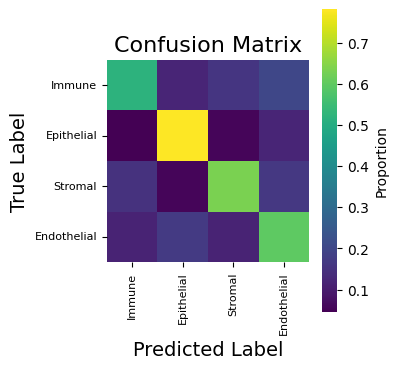


L12 sublineage
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/conf_matrix_level12.pdf


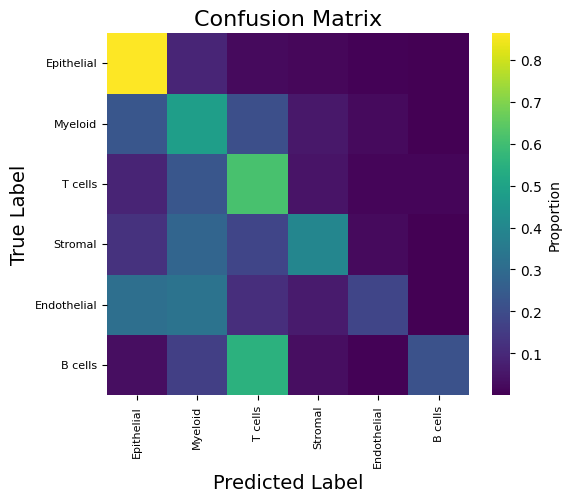

Skip L3 CNiche: no val_preds_level3 (re-run ablation cell after reload model/base)
Skip L4 TNiche: no val_preds_level4 (re-run ablation cell after reload model/base)
Skip L1 agg vs L1 head agreement: different evaluation scopes (1,385,776 OOF rows vs 1,092,742 in-sample cells)
Saved: conf_matrix_level2 / level1 / level12 (+ L1head if available)


In [9]:
# L2 OOF (cross-dataset)
hcc_cli.step_pooled_he_validate(pooled_ctx)

# Extra: L1 + L12 confusion from best-fold model on all pooled cells
g = pooled_ctx.g
_nbr = g.get("spatial_neighbor_index")
ensure_lp_extra_insample_preds(
    g["model"],
    scaler,
    cv_data,
    device,
    predict_all_label_heads,
    g,
    neighbor_index=_nbr,
)

g["class_names"] = class_names
g["class_names_level1"] = class_names_level1
g["class_names_level12"] = class_names_level12

print("\n[Three-level internal] confusion matrices →", pooled_result_dir)
plot_he_confusion_matrices(plot_confusion_matrix, pooled_result_fig, cv_data, g)
print("Saved: conf_matrix_level2 / level1 / level12 (+ L1head if available)")


## 4. StarDist predict (each dataset) — three levels

For each MATCHED_HE with `{sample}_matched_features_stardist.h5ad`:

Outputs under `s4769/{save_result}/stardist/{sample}/`:
- Spatial: `celltype_pred_stardist_level{2,1,12}.jpg`
- ROC: `roc_stardist_level{2,1,1_L1head,12}.pdf`
- Metrics (L2): `validation_external_stardist_matched_*.csv`


### Run StarDist one level at a time

`step_pooled_stardist(pooled_ctx)` without `levels=` runs **all three heads** (L2, L1, L12).

To run a single tier, pass e.g. `levels=["l2"]`. Valid keys: `l2`, `l1`, `l12`.

- **L2 only** writes `validation_external_stardist_matched_*.csv`.
- Other tiers write spatial / ROC / AUROC table for that head.
- Optional: `samples=POOLED_SAMPLES[:1]` to test on one region first.


In [ ]:
import importlib
importlib.reload(hcc_cli)

from uni_label_cv_helpers import make_pooled_stardist_result_fig

_TIER_CHECKS = {
    "l2": ("L2 celltype (final_CT)", "stardist_pred_level2", "roc_stardist_level2"),
    "l1": ("L1 lineage (final_lineage)", "stardist_pred_level1", "roc_stardist_level1"),
    "l12": ("L12 sublineage (final_sublineage)", "stardist_pred_level12", "roc_stardist_level12"),
}


def check_stardist_level(level, sample=None):
    # Print spatial/ROC file status for one tier on one sample.
    demo = sample or POOLED_SAMPLES[0]
    title, spatial_key, roc_key = _TIER_CHECKS[level.lower()]
    rf, _ = make_pooled_stardist_result_fig(DATA_ROOT, demo, save_result)
    sp, rc = rf(spatial_key), rf(roc_key)
    print(
        f"{title} ({demo}): "
        f"spatial={'OK' if Path(sp).is_file() else 'MISSING'} | "
        f"ROC={'OK' if Path(rc).is_file() else 'MISSING'}"
    )


def ensure_stardist_h5ads(samples=None, build=True):
    # Build missing {sample}_matched_features_stardist.h5ad via CLI helper.
    samples = list(samples) if samples is not None else list(POOLED_SAMPLES)
    n_missing = 0
    for s in samples:
        p = CASES_ROOT / s / f"{s}_matched_features_stardist.h5ad"
        if p.is_file():
            continue
        n_missing += 1
        if not build:
            print(f"  MISSING StarDist h5ad: {p}")
            continue
        print(f"Building StarDist h5ad for {s} ...", flush=True)
        ctx = hcc_cli.RunContext(
            sample=s,
            cases_root=CASES_ROOT,
            python_root=Path(path),
            therapy_data=s,
            therapy_model=hcc_cli.DEFAULT_THERAPY_MODEL,
            save_result="result",
            device=device,
            seed=SEED,
            match_tolerance=1.0,
            column_rename=dict(hcc_cli.HCC_COLUMN_RENAME),
            force_rebuild_h5ad=False,
            input_dim=None,
            hidden_dims=POOLED_HIDDEN_DIMS,
            cv_k=5,
            stratify_target="joint",
            patience=10,
            max_epochs=50,
            train_batch_size=4096,
            resume_from_checkpoints=True,
            ablation_tag=POOLED_ABLATION_TAG,
            hce_w1=1.0, hce_w2=2.0, hce_w12=1.0, hce_w_l12head=1.0, hce_w_l3=1.0, hce_w_l4=1.0,
            build_stardist_h5ad=True,
            acq_id=_acq_map[s],
            stardist_root=hcc_cli.DEFAULT_STARDIST_ROOT,
            use_spatial_context=POOLED_USE_SPATIAL,
            spatial_k=POOLED_SPATIAL_K,
            spatial_mode=POOLED_SPATIAL_MODE,
        )
        hcc_cli._ensure_stardist_h5ad(ctx)
    print(f"StarDist h5ad: {len(samples) - n_missing} existing, built/attempted {n_missing}")


ensure_stardist_h5ads()


### L2 celltype / final_CT (StarDist)


In [ ]:
hcc_cli.step_pooled_stardist(pooled_ctx, levels=["l2"])
check_stardist_level("l2")


### L1 lineage / final_lineage (StarDist)


In [ ]:
hcc_cli.step_pooled_stardist(pooled_ctx, levels=["l1"])
check_stardist_level("l1")


### L12 sublineage / final_sublineage (StarDist)


In [ ]:
hcc_cli.step_pooled_stardist(pooled_ctx, levels=["l12"])
check_stardist_level("l12")


In [ ]:
# Summary check for all three tiers on first sample
print(f"StarDist outputs: {pooled_result_dir / 'stardist'}")
for level in ("l2", "l1", "l12"):
    check_stardist_level(level)


In [ ]:
# Optional: inspect L2 metrics / AUROC CSV for one sample
_demo = POOLED_SAMPLES[0]
_rf, _ = make_pooled_stardist_result_fig(DATA_ROOT, _demo, save_result)
_metrics = _rf("validation_external_stardist_matched_metrics")
_auroc = _auroc_csv_path_from_metrics(_metrics)
print(f"Demo: {_demo}")
print(" metrics:", _metrics)
print(" AUROC:", _auroc)
if Path(_metrics).is_file():
    display(pd.read_csv(_metrics).tail(1).T)


### L1 / L12 — detailed file list


In [ ]:
# Inspect L1 + L12 outputs for one sample
_demo = POOLED_SAMPLES[0]
_rf, _ = make_pooled_stardist_result_fig(DATA_ROOT, _demo, save_result)
_tiers = {
    "L1": ("stardist_pred_level1", "roc_stardist_level1", "roc_stardist_level1_L1head"),
    "L12": ("stardist_pred_level12", "stardist_true_level12", "roc_stardist_level12"),
}
for tier, keys in _tiers.items():
    print(f"\n{tier}:")
    for key in keys:
        p = Path(_rf(key))
        print(f"  {'✓' if p.is_file() else '✗'} {p.name}")


## 5. StarDist predict on all nuclei of 36 StarDist_Segment

Unlike **§4**, which evaluates matched CODEX-annotated nuclei with ground truth and AUROC, this section uses the UNI embedding to predict **every StarDist nucleus** in each HCC sample.

Build each input with:

`conda run --no-capture-output -n SeededNTM python -u code/CODEX_hcc/transer_embedding_label_h5ad.py --sample {MATCHED_HE} --steps stardist_all_h5ad`

**Input:** `data/CODEX/HCC/Michael_data_transfer/s4769/HE/{sample}/{sample}_all_features_stardist.h5ad`

**Output:** `data/CODEX/HCC/Michael_data_transfer/s4769/{save_result}/stardist/{sample}/{sample}_all_features_stardist_label.h5ad`

The pooled HCC checkpoint predicts three heads only: `l2` (`final_CT`), `l12` (`final_sublineage`), and `l1` (`final_lineage`). The class-name order for each probability head is stored in `adata.uns['pred_prob_class_names']`.

There is no matched-ground-truth AUROC here because the prediction covers all StarDist nuclei. Spatial-context models build their neighbor graph from the StarDist centroids. Run **§2** first to create the required pooled checkpoint.



```python
conda run --no-capture-output -n SeededNTM python -u \
code/CODEX_hcc/transer_embedding_label_h5ad.py \
--steps stardist_all_h5ad
```

In [10]:
# Requires pooled_ctx.g from §2 and uses the pooled HCC three-head checkpoint.
# Each sample needs {sample}_all_features_stardist.h5ad in its HCC HE directory.
from uni_label_cv_helpers import stardist_all_label_h5ad_path

if "BEST_MLP_CHECKPOINT" not in pooled_ctx.g:
    raise RuntimeError("Run §2 (step_pooled_train) first.")

hcc_cli.step_pooled_stardist_all(pooled_ctx)

print(f"StarDist-all label h5ads → {pooled_result_dir / 'stardist'}")
for sample in POOLED_SAMPLES[:5]:
    out = stardist_all_label_h5ad_path(DATA_ROOT, sample, save_result)
    if out.is_file():
        print(f"  {sample}: {out.name}")
if len(POOLED_SAMPLES) > 5:
    print(f"  ... +{len(POOLED_SAMPLES) - 5} more samples")



[Pooled StarDist all nuclei] 36 datasets
Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_bs4096/best_mlp_gpu.pt
  Using provided hidden_dims: [1024, 512, 256]
✓ StarDist model loaded
  awy-98938_aligned_0d535a74: saved awy-98938_aligned_0d535a74_all_features_stardist_label.h5ad (42,877 cells; 22 prob columns; heads=['l1', 'l12', 'l2'])
Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_bs4096/best_mlp_gpu.pt
  Using provided hidden_dims: [1024, 512, 256]
✓ StarDist model loaded
  awy-98938_aligned_8ded610e: saved awy-98938_aligned_8ded610e_all_features_stardist_label.h5ad (16,896 cells; 22 prob columns; heads=['l1', 'l12', 'l2'])
Loading best model for StarDist prediction...
  Checkpoint file:

In [19]:
import anndata as ad

# Inspect the first pooled HCC sample without loading the full matrix into memory.
_demo = POOLED_SAMPLES[0]
_demo_h5ad = stardist_all_label_h5ad_path(DATA_ROOT, _demo, save_result)
print(f"Demo: {_demo}\n  {_demo_h5ad}")
if _demo_h5ad.is_file():
    _a = ad.read_h5ad(_demo_h5ad, backed="r")
    try:
        prob_cols = [c for c in _a.obs.columns if "_prob_" in c]
        print(f"  n_obs={_a.n_obs:,}  prob columns={len(prob_cols)}")
        print(f"  heads in uns: {list(_a.uns.get('pred_prob_class_names', {}).keys())}")
        print(f"  sample obs cols: {list(_a.obs.columns[:8])} ...")
    finally:
        # Close the backed AnnData file handle after inspection.
        _a.file.close()
else:
    print("  (file not found — run the cell above first)")


Demo: awy-98938_aligned_0d535a74
  /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/stardist/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_all_features_stardist_label.h5ad
  n_obs=42,877  prob columns=22
  heads in uns: ['l1', 'l12', 'l2']
  sample obs cols: ['cell_id', 'centroid_x', 'centroid_y', 'probability', 'l2_prob_0', 'l2_prob_1', 'l2_prob_2', 'l2_prob_3'] ...


In [11]:
# Uncomment to run all three heads for every pooled sample in one pass:
# hcc_cli.step_pooled_stardist(pooled_ctx, levels=["l2", "l1", "l12"])
# for level in ("l2", "l1", "l12"):
#     check_stardist_level(level)
print("Skip by default — use per-level cells in §4, or uncomment above.")


Skip by default — use per-level cells in §4, or uncomment above.


## 6. StarDist predict on all nuclei of 8 StarDist_Segment rest regions

Unlike **§5** (36 annotated `StarDist_Segment` regions), this section runs the same pooled HCC checkpoint on the **8 MATCHED_HE keys that have StarDist CSVs but no CODEX cell-type annotation**.

They live in `data/CODEX/HCC/StarDist_Segment/` (not a separate `StarDist_Segment_hcc_rest` folder). Analog of lung `Incomplete_Cases`.

Build each missing input with:

`conda run --no-capture-output -n SeededNTM python -u code/CODEX_hcc/transer_embedding_label_h5ad.py --sample {MATCHED_HE} --steps stardist_all_h5ad --stardist-root data/CODEX/HCC/StarDist_Segment`

**Input:** `data/CODEX/HCC/Michael_data_transfer/s4769/HE/{sample}/{sample}_all_features_stardist.h5ad`

**Output (separate from §5):** `data/CODEX/HCC/Michael_data_transfer/s4769/{save_result}/stardist_hcc_rest/{sample}/{sample}_all_features_stardist_label.h5ad`

Three heads only: `l2` / `l12` / `l1`. No matched-ground-truth AUROC. Run **§2** first.


In [20]:
# Requires pooled_ctx.g from §2. Same checkpoint as §5; writes stardist_hcc_rest/ (not stardist/).
from uni_label_cv_helpers import stardist_hcc_rest_all_label_h5ad_path

REST_SAMPLES_ALL = hcc_cli.discover_hcc_rest_samples(
    CASES_ROOT, hcc_cli.DEFAULT_STARDIST_ROOT, require_h5ad=False,
)
REST_SAMPLES = hcc_cli.discover_hcc_rest_samples(
    CASES_ROOT, hcc_cli.DEFAULT_STARDIST_ROOT, require_h5ad=True,
)
print(f"StarDist_Segment rest (no CODEX annotation): {len(REST_SAMPLES_ALL)}")
for sample in REST_SAMPLES_ALL:
    h5ad = CASES_ROOT / sample / f"{sample}_all_features_stardist.h5ad"
    print(f"  {sample}: all_features_stardist.h5ad={'OK' if h5ad.is_file() else 'MISSING'}")
print(f"Ready for inference: {len(REST_SAMPLES)}")

if "BEST_MLP_CHECKPOINT" not in pooled_ctx.g:
    raise RuntimeError("Run §2 (step_pooled_train) first.")

hcc_cli.step_pooled_stardist_all_hcc_rest(pooled_ctx, REST_SAMPLES)

print(f"StarDist-all rest label h5ads → {pooled_result_dir / 'stardist_hcc_rest'}")
for sample in REST_SAMPLES[:5]:
    out = stardist_hcc_rest_all_label_h5ad_path(DATA_ROOT, sample, save_result)
    if out.is_file():
        print(f"  {sample}: {out.name}")
if len(REST_SAMPLES) > 5:
    print(f"  ... +{len(REST_SAMPLES) - 5} more samples")


StarDist_Segment rest (no CODEX annotation): 8
  awm-10421_aligned_to_FinalLiv-27_c001_v001_r001_reg029: all_features_stardist.h5ad=OK
  awm-10421_aligned_to_FinalLiv-27_c001_v001_r001_reg030: all_features_stardist.h5ad=OK
  clk-37422_aligned_to_FinalLiv-27_c002_v001_r001_reg001: all_features_stardist.h5ad=OK
  clk-37422_aligned_to_FinalLiv-27_c002_v001_r001_reg002: all_features_stardist.h5ad=OK
  dpn-56105_aligned_93258926: all_features_stardist.h5ad=OK
  mwc-11504_aligned_to_FinalLiv-27_c001_v001_r001_reg031: all_features_stardist.h5ad=OK
  mwc-11504_aligned_to_FinalLiv-27_c001_v001_r001_reg032: all_features_stardist.h5ad=OK
  xid-87175_aligned_f82fb393: all_features_stardist.h5ad=OK
Ready for inference: 8

[Pooled StarDist all nuclei — HCC rest] 8 datasets
Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_bs4096/best_mlp_gpu.pt
  Using p

In [21]:
import anndata as ad

# Inspect the first rest sample with a written label h5ad.
_rest_demo = next(
    (
        s for s in REST_SAMPLES
        if stardist_hcc_rest_all_label_h5ad_path(DATA_ROOT, s, save_result).is_file()
    ),
    None,
)
if _rest_demo is None:
    print("No rest label h5ad yet — run the cell above (and build missing *_all_features_stardist.h5ad).")
else:
    _rest_h5ad = stardist_hcc_rest_all_label_h5ad_path(DATA_ROOT, _rest_demo, save_result)
    print(f"Demo rest: {_rest_demo}\n  {_rest_h5ad}")
    _a = ad.read_h5ad(_rest_h5ad, backed="r")
    try:
        prob_cols = [c for c in _a.obs.columns if "_prob_" in c]
        print(f"  n_obs={_a.n_obs:,}  prob columns={len(prob_cols)}")
        print(f"  heads in uns: {list(_a.uns.get('pred_prob_class_names', {}).keys())}")
        print(f"  sample obs cols: {list(_a.obs.columns[:8])} ...")
    finally:
        _a.file.close()


Demo rest: awm-10421_aligned_to_FinalLiv-27_c001_v001_r001_reg029
  /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/stardist_hcc_rest/awm-10421_aligned_to_FinalLiv-27_c001_v001_r001_reg029/awm-10421_aligned_to_FinalLiv-27_c001_v001_r001_reg029_all_features_stardist_label.h5ad
  n_obs=21,336  prob columns=22
  heads in uns: ['l1', 'l12', 'l2']
  sample obs cols: ['cell_id', 'centroid_x', 'centroid_y', 'probability', 'l2_prob_0', 'l2_prob_1', 'l2_prob_2', 'l2_prob_3'] ...


### Plot cell type

In [27]:
## Predicted spatial maps: 8 rest samples × L2 / L12 / L1 (pred-only).
## JPGs: stardist_hcc_rest/{sample}/{sample}_stardist_pred_{l2,l12,l1}.jpg
import importlib
import uni_label_cv_helpers as uni_nb
import s4769_plot
importlib.reload(uni_nb)
importlib.reload(s4769_plot)

if "REST_SAMPLES" not in globals() or not REST_SAMPLES:
    REST_SAMPLES = hcc_cli.discover_hcc_rest_samples(
        CASES_ROOT, hcc_cli.DEFAULT_STARDIST_ROOT, require_h5ad=True,
    )

print(f"Plotting rest samples × {s4769_plot.HCC_STARDIST_MACRO_AUROC_TIERS}")
rest_spatial = s4769_plot.plot_hcc_rest_stardist_spatial_maps(
    DATA_ROOT, REST_SAMPLES, save_result, pan_organ=hcc_cli.PAN_ORGAN,
)


Plotting rest samples × ('l2', 'l12', 'l1')
  awm-10421 reg029: n=21,336
Number of valid data points: 21336
Number of cell types: 12
  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/stardist_hcc_rest/awm-10421_aligned_to_FinalLiv-27_c001_v001_r001_reg029/awm-10421_aligned_to_FinalLiv-27_c001_v001_r001_reg029_stardist_pred_l2.jpg
  saved awm-10421_aligned_to_FinalLiv-27_c001_v001_r001_reg029_stardist_pred_l2.jpg
Number of valid data points: 21336
Number of cell types: 5
  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/stardist_hcc_rest/awm-10421_aligned_to_FinalLiv-27_c001_v001_r001_reg029/awm-10421_aligned_to_FinalLiv-27_c001_v001_r001_reg029_stardist_pred_l12.jpg
  saved awm-10421_aligned_to_FinalLiv-27_c001_v001_r001_reg029_stardist_pred_l12.jpg
Number of valid data points: 21336
Number of cell types: 4
  Saved predicted spa

Overview → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/stardist_hcc_rest/rest_spatial_pred_overview_l2_l12_l1.jpg


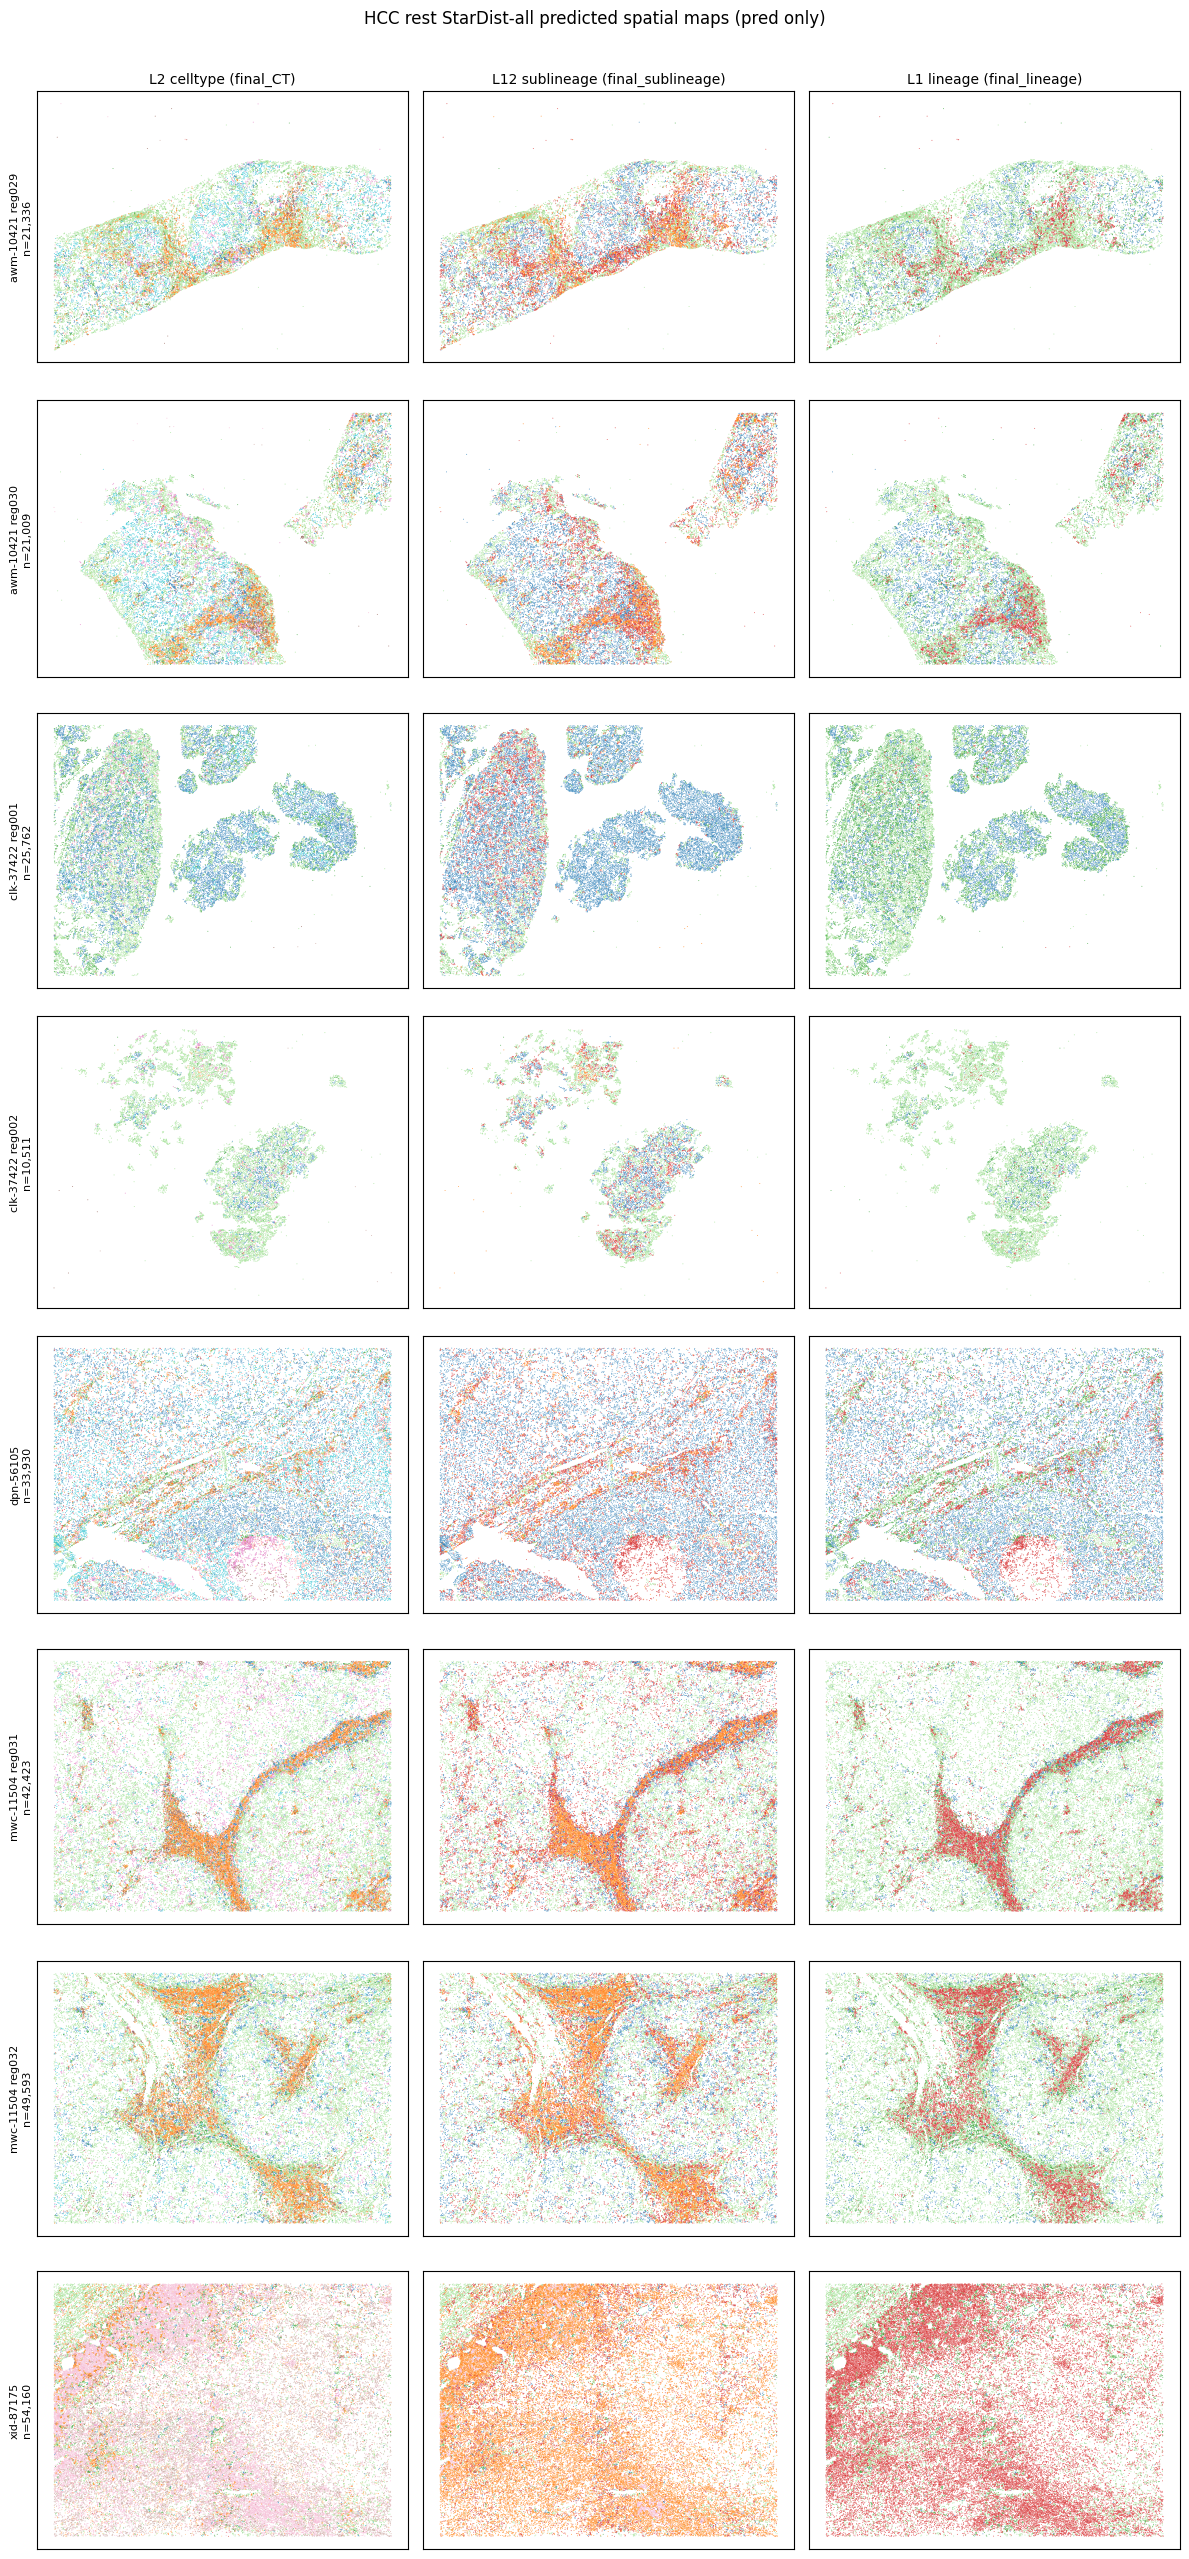

In [30]:
s4769_plot.plot_hcc_rest_stardist_spatial_overview(
    rest_spatial, DATA_ROOT, save_result,
    pan_organ=hcc_cli.PAN_ORGAN, point_size=0.5,
)


## Notes

- HCC has **no** CNiche/TNiche (L3/L4); only L2 / L12 / L1.
- §5 writes `stardist/` for the 36 annotated regions; §6 writes `stardist_hcc_rest/` for the 8 StarDist-only regions.
- Per-sample notebook: `HCC_train_validate_cv_UNIlabel_single.ipynb`
- Batch CLI: `HCC_train_validate_cv_UNIlabel.py --mode cross-dataset`
